In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from itertools import chain
from collections import Counter, defaultdict

In [2]:
path = "NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
data = pd.read_csv(path, skiprows=4, sep="\t", header=None, engine="python")
data.head()

,0,1,2,3,4,5
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


In [3]:
data = data.drop(columns=0)
data.columns = ["art_id", "keyword", "country_code", "text", "label"]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   art_id        10469 non-null  object
 1   keyword       10469 non-null  object
 2   country_code  10469 non-null  object
 3   text          10468 non-null  object
 4   label         10469 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 409.1+ KB


In [4]:
# deal with na in text
eda_data = data.dropna(subset="text").copy()
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10468 entries, 0 to 10468
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   art_id        10468 non-null  object
 1   keyword       10468 non-null  object
 2   country_code  10468 non-null  object
 3   text          10468 non-null  object
 4   label         10468 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 490.7+ KB


In [10]:
# Basic Statistical Profiling
# 1) Token Count:average, minimum, and maximum sentence length
eda_data["char_len"] = eda_data["text"].str.len()
eda_data["token_len"] = eda_data["text"].str.split().str.len()
avg_len_char = eda_data["char_len"].mean()
min_len_char = eda_data["char_len"].min()
max_len_char = eda_data["char_len"].max()
avg_len_token = eda_data["token_len"].mean()
min_len_token = eda_data["token_len"].min()
max_len_token = eda_data["token_len"].max()

print(f"Average Length per char: {avg_len_char:.2f}, Minimum Length: {min_len_char}, Maximum Length: {max_len_char}")
print(f"Average Length per token: {avg_len_token:.2f}, Minimum Length: {min_len_token}, Maximum Length: {max_len_token}")

# 2) Vocabulary Size
eda_clean_data = eda_data.copy()
clean = (eda_clean_data["text"].str.lower().str.replace(r"[^a-z0-9\s]+", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip().str.split())
vocab = set(chain.from_iterable(clean))
print(f"Vocabulary Size is {len(vocab)}")

# 3) Class Distribution
count = eda_clean_data["label"].value_counts()
num_0 = count.get(0, 0)
num_1 = count.get(1, 0)
num_2 = count.get(2, 0)
num_3 = count.get(3, 0)
num_4 = count.get(4, 0)
print(f"No PCL: {num_0+num_1}, PCL: {num_2+num_3+num_4}")

Average Length per char: 266.54, Minimum Length: 8, Maximum Length: 5493
Average Length per token: 48.43, Minimum Length: 1, Maximum Length: 909
Vocabulary Size is 30037
No PCL: 9475, PCL: 993


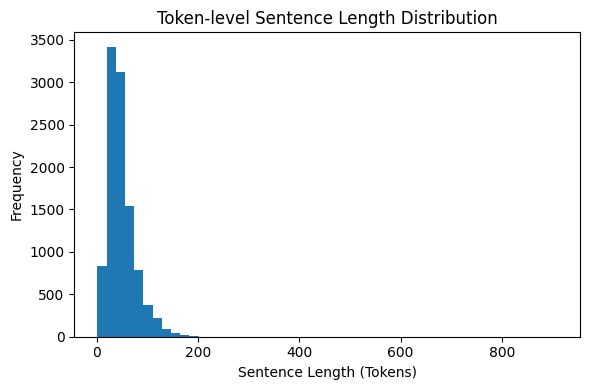

In [13]:
plt.figure(figsize=(6,4))
plt.hist(eda_data["token_len"], bins=50)
plt.xlabel("Sentence Length (Tokens)")
plt.ylabel("Frequency")
plt.title("Token-level Sentence Length Distribution")
plt.tight_layout()
plt.show()


**Analyis**: Basic statistical profiling reveals several key structural characteristics of the PCL dataset. In terms of sentence length, the dataset exhibits substantial variability. At the character level, the average length is 266.54 characters, while the maximum length reaches 5,493 characters, indicating the presence of extreme outliers. At the token level, the average sentence length is 48.43 tokens, with a maximum of 909 tokens. Figure 1 illustrates the distribution of token-level sentence lengths, showing a strongly right-skewed, long-tailed pattern. Together, these statistics show a strongly right-skewed, long-tailed distribution, where most instances are relatively short but a small number of samples are significantly longer than average.

The vocabulary size after basic normalisation is 30,037 unique tokens, suggesting moderate lexical diversity within the corpus. This indicates that the dataset contains a wide range of lexical forms, but is not excessively sparse at the word level.

Finally, the class distribution is highly imbalanced. Following the official binary mapping of the labels, there are 9,475 No PCL instances compared to only 993 PCL instances. This imbalance highlights that positive PCL examples constitute a relatively small fraction of the dataset.

**Impact Statement**: The statistical characteristics identified through basic profiling directly inform the design of our PCL classification approach. The long-tailed token length distribution suggests that most instances can be adequately represented using a moderate maximum input length, while a small number of extremely long samples may require truncation. This motivates a trade-off between information coverage and computational efficiency during tokenisation.

Furthermore, the pronounced class imbalance, with PCL instances comprising a small minority of the dataset, highlights the inadequacy of accuracy as an evaluation metric and motivates the use of the F1 score on the positive (PCL) class. It also suggests that imbalance-aware strategies, such as class weighting or threshold tuning, may be beneficial during model training.

Finally, the observed vocabulary size indicates sufficient lexical diversity to warrant the use of contextualised language models, which are better suited to capturing nuanced linguistic patterns than models relying solely on surface-level lexical features.

In [ ]:
#  Lexical Analysis
# 1) N-gram Analysis
# Bigram
def count_ngram(N, data):
    count = Counter()
    for sentence in data:
        if len(sentence) < N:
            continue
        streams = (sentence[i:] for i in range(N))
        count.update(zip(*streams))

    return count

clean_pcl = clean[eda_data["label"].isin([2,3,4])]
clean_no_pcl = clean[eda_data["label"].isin([0,1])]
count_2_pcl = count_ngram(2, clean_pcl)
count_2_npcl = count_ngram(2, clean_no_pcl)
count_3_pcl = count_ngram(3, clean_pcl)
count_3_npcl = count_ngram(3, clean_no_pcl)
count_2_all = count_ngram(2, clean)
count_3_all = count_ngram(3, clean)

print(count_2_pcl.most_common(10))
print(count_2_npcl.most_common(10))
print(count_3_pcl.most_common(10))
print(count_3_npcl.most_common(10))
print(count_2_all.most_common(10))
print(count_3_all.most_common(10))


# 2） Stop Word Density (the is at)
filler = {"the","is","at","a","an","and","to","of","in","on","for","with"}
def count_filler(data, filler):
    filler_count = 0
    total_len = 0
    for sentence in data:
        total_len += len(sentence)
        for word in sentence:
            if word in filler:
                filler_count += 1
    return filler_count, total_len

filler_count_pcl, total_len_pcl = count_filler(clean_pcl, filler)
filler_count_npcl, total_len_npcl = count_filler(clean_no_pcl, filler)
filler_count, total_len = count_filler(clean, filler)

print(f"the rate of filler word in PCl is {filler_count_pcl / total_len_pcl :.4f}")
print(f"the rate of filler word in no PCl is {filler_count_npcl / total_len_npcl :.4f}")
print(f"the rate of filler word is {filler_count / total_len :.4f}")
        


    

[(('of', 'the'), 286), (('in', 'the'), 220), (('in', 'need'), 184), (('poor', 'families'), 150), (('to', 'the'), 146), (('for', 'the'), 123), (('to', 'be'), 94), (('n', 't'), 87), (('on', 'the'), 83), (('it', 'is'), 82)]
[(('of', 'the'), 2421), (('in', 'the'), 2203), (('to', 'the'), 1167), (('in', 'need'), 841), (('poor', 'families'), 771), (('for', 'the'), 749), (('on', 'the'), 728), (('and', 'the'), 653), (('to', 'be'), 646), (('n', 't'), 600)]
[(('those', 'in', 'need'), 52), (('in', 'need', 'of'), 47), (('from', 'poor', 'families'), 41), (('do', 'n', 't'), 26), (('to', 'those', 'in'), 21), (('people', 'in', 'need'), 19), (('poor', 'families', 'and'), 18), (('a', 'lot', 'of'), 16), (('ca', 'n', 't'), 16), (('are', 'in', 'need'), 15)]
[(('in', 'need', 'of'), 547), (('from', 'poor', 'families'), 189), (('one', 'of', 'the'), 179), (('do', 'n', 't'), 176), (('as', 'well', 'as'), 142), (('the', 'united', 'states'), 138), (('the', 'number', 'of'), 129), (('the', 'most', 'vulnerable'), 112)

[(('in', 'need'), 184), (('poor', 'families'), 150), (('to', 'be'), 94), (('n', 't'), 87), (('it', 'is'), 82), (('from', 'the'), 68), (('to', 'help'), 65), (('who', 'are'), 57), (('those', 'in'), 55), (('the', 'homeless'), 50)]
[(('in', 'need'), 841), (('poor', 'families'), 771), (('to', 'be'), 646), (('n', 't'), 600), (('need', 'of'), 555), (('by', 'the'), 510), (('that', 'the'), 504), (('from', 'the'), 467), (('it', 'is'), 415), (('the', 'country'), 392)]


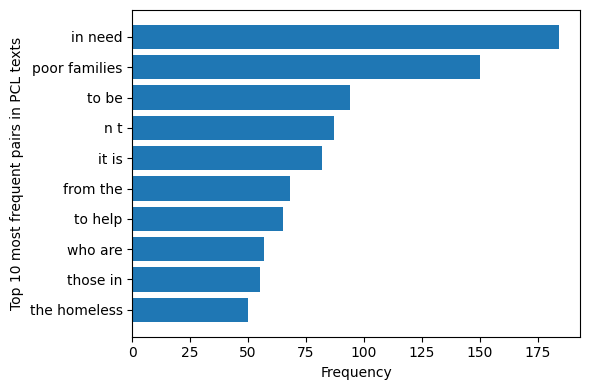

In [21]:
# Filter bigrams of all fillers
def filter_ngrams(counter, stopwords):
    return Counter({ng: c for ng, c in counter.items()
                    if not all(w in stopwords for w in ng)})

count_2_pcl_f = filter_ngrams(count_2_pcl, filler)
count_2_npcl_f = filter_ngrams(count_2_npcl, filler)

print(count_2_pcl_f.most_common(10))
print(count_2_npcl_f.most_common(10))

top_grams = count_2_pcl_f.most_common(10)
labels = [" ".join(pair) for pair, _ in top_grams]
counts = [nums for _, nums in top_grams]

plt.figure(figsize=(6, 4))
plt.barh(labels, counts)
plt.xlabel("Frequency")
plt.ylabel("Top 10 most frequent pairs in PCL texts")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Analysis.
We conduct lexical analysis to examine word-level patterns associated with Patronising and Condescending Language (PCL). Figure 2 presents the top-10 most frequent bigrams in PCL instances after removing bigrams composed solely of stopwords. Several high-frequency bigrams explicitly reference vulnerability or dependency, such as “in need” and “poor families”. This indicates that PCL texts often co-occur with recurring lexical constructions describing disadvantaged social groups or individuals requiring assistance.

In contrast, many frequent bigrams, including “to be”, “it is”, and “from the”, also appear in PCL instances despite carrying little semantic content on their own. This suggests that surface-level lexical patterns are not uniquely associated with PCL and may overlap substantially with non-PCL texts.

We further analyse stopword density to compare the proportion of function words across classes. The stopword ratio in PCL texts (0.2392) is slightly higher than in No PCL texts (0.2303), while the overall dataset exhibits a stopword ratio of 0.2313. This small difference indicates that PCL is not characterised by a strong shift in filler-word usage, but rather by differences in content-bearing expressions and contextual framing.

Impact Statement. 
The lexical analysis indicates that PCL instances are frequently associated with recurring phrases describing vulnerability and dependency, such as “in need” and “poor families”. While these word-level cues provide useful signals, the presence of semantically weak bigrams (e.g., “to be”, “it is”) and the substant|ial overlap of frequent n-grams across PCL and No PCL texts suggest that lexical features alone are insufficient for reliable PCL detection. This insight motivates the use of contextualised language models, which can disambiguate similar lexical expressions based on surrounding context and reduce false positives arising from keyword-based reasoning. In addition, the limited difference in stopword density between classes suggests that PCL is characterised more by semantic framing than by superficial stylistic differences, reinforcing the need for models that capture contextual and pragmatic information